# Imports

In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from rasterio.plot import show
import pandas as pd
import os
from datetime import datetime
import contextily as ctx
from shapely.geometry import Polygon, Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import copy
import netCDF4 as nc
import h5py


# Functions

In [2]:
def get_poly_rain(x, y, radar_gdf):
    """
    Calculates the rain value of the grid point

    Parameters:
    - x: float or int, the x-coordinate of the point of interest
    - y: float or int, the y-coordinate of the point of interest
    - radar_gdf: GeoDataFrame, a GeoDataFrame object containing radar data with rain values and corresponding geometry information

    Return:
    - poly_rain: float, the average rain value of the four grid points within the square polygon centered around the point of interest

    Notes:
    - The point of interest should be within the extent of the GeoDataFrame object.
    - The function assumes that the GeoDataFrame object has a "rain" column and a "geometry" column containing Point objects.
    """

    # create a Point object from the (x, y) coordinates
    cord1 = Point(x, y)

    # use .contains() to identify the row(s) that contain the point of interest
    cord_row1 = radar_gdf["geometry"].contains(cord1)

    # extract the rain value from the corresponding row
    rain_value1 = radar_gdf.loc[cord_row1, "rain"].iloc[0]

    # Calculate the average of 4 grid points
    poly_rain = rain_value1
    return poly_rain

In [3]:
def process_radar_data(radar_filename, time_step=0):
    """
    Process radar data from a given file and returns a GeoDataFrame with polygon grid and rain values.

    Parameters:
    - radar_filename: str, the filename/path of the radar data file

    Returns:
    - radar_poly_grid_gdf: GeoDataFrame, a GeoDataFrame object containing polygon grid and rain values
    """
    # Load radar data
    radar_data = sio.loadmat(radar_filename)
    
    # Find the time step
    time = radar_data['event_file'][0][0][1].ravel()[time_step]
    time = pd.to_datetime(time-719529, unit='D').round('1min')
    
    ## define geo parm --- Meter Unit
    length = 500 ; width = 500 ; cellsize = 500
    xll = radar_data['event_file']['xll'][0][0][0][0] 
    yll = radar_data['event_file']['yll'][0][0][0][0]

    # Extract the rain data
    rain_array_3d = radar_data['event_file'][0][0][0]  # access the array inside the dictionary
    rain_array_2d = rain_array_3d[:,:,time_step]  ## access only one time slice !! 
    
    # Create 1D arrays of the X and Y coordinates
    y = np.arange(yll, yll + cellsize * rain_array_2d.shape[0], cellsize)
    x = np.arange(xll, xll + cellsize * rain_array_2d.shape[1], cellsize)

    # Create a 2D grid of X and Y coordinates
    xx, yy = np.meshgrid(x, y)

    # Reshape the arrays into 1D arrays
    x_flat = xx.ravel()
    y_flat = yy.ravel()
    rain_flat = rain_array_2d.flatten()

    # Calculate rain values for all grid points
    radar_df = pd.DataFrame({'x': x_flat, 'y': y_flat, 'rain': rain_flat})
    
    # Create polygons and assign rain values
    polygons = []
    for index, row in radar_df.iterrows():
        x = row['x']
        y = row['y']
        rain = row['rain']

        # Define polygon coordinates
        polygon = Polygon([(x, y), (x + width, y), (x + width, y + length), (x, y + length)])

        # Append polygon and rain value to list
        polygons.append(polygon)

    # Create GeoDataFrame from the list of polygons
    radar_poly_grid_gdf = gpd.GeoDataFrame(geometry=polygons, crs='epsg:2039')
    radar_poly_grid_gdf['rain'] = radar_df['rain']
    return radar_poly_grid_gdf, time


In [4]:
def netCDF_process_radar_data(radar_filename, start_idx, array_len_idx, time_step=0):
    """
    Process radar data from a given file and returns a GeoDataFrame with polygon grid and rain values.
    !!! PAY ATTANTION!!! ->> this function change the values beloew 1 to 0!! 
    Parameters:
    - radar_filename: str, the filename/path of the radar data file

    Returns:
    - radar_poly_grid_gdf: GeoDataFrame, a GeoDataFrame object containing polygon grid and rain values
    """
    # Load radar data
    radar_nc = nc.Dataset(radar_filename)
    # Define interest area by grid location
    eastings = radar_nc.variables['eastings'][start_idx:start_idx+array_len_idx]   
    northings = np.flip(radar_nc.variables['northings'])[start_idx:start_idx+array_len_idx]
#     eastings = radar_nc.variables['eastings'][100:100+400]   
#     northings = np.flip(radar_nc.variables['northings'])[150:150+400]
    # Find the time step
    times = radar_nc['time'][:]
    times = pd.to_datetime(times-719529, unit='D')
    time = times[[time_step]]
    ## define geo parm --- Meter Unit
    length = 500 ; width = 500 ; cellsize = 500
    xll = eastings[0] ; yll = northings[0]

    # Extract the rain data
    rain_rate = radar_nc.variables['rainrate_mmh'][:] # access the array inside the dictionary
    rain_array_2d = rain_rate[time_step, start_idx:start_idx+array_len_idx, start_idx:start_idx+array_len_idx] 
    rain_array_2d = np.flip(rain_array_2d, axis=1)
    # Transpose the flipped matrix
    rain_array_2d = np.transpose(rain_array_2d)
    # Create a masked array where values less than 1 are masked
    # !!! PAY ATTANTION!!! ->> this function change the values beloew 1 to 0!! 
    rain_array_2d = np.ma.masked_less(rain_array_2d, 1)

    # Create a 2D grid of X and Y coordinates
    xx, yy = np.meshgrid(eastings, northings)

    # Reshape the arrays into 1D arrays
    x_flat = xx.ravel()
    y_flat = yy.ravel()
    rain_flat = rain_array_2d.flatten()

    # Calculate rain values for all grid points
    radar_df = pd.DataFrame({'x': x_flat, 'y': y_flat, 'rain': rain_flat})
    
    # Create polygons and assign rain values
    polygons = []
    for index, row in radar_df.iterrows():
        x = row['x']
        y = row['y']
        rain = row['rain']

        # Define polygon coordinates
        polygon = Polygon([(x, y), (x + width, y), (x + width, y + length), (x, y + length)])

        # Append polygon and rain value to list
        polygons.append(polygon)

    # Create GeoDataFrame from the list of polygons
    radar_poly_grid_gdf = gpd.GeoDataFrame(geometry=polygons, crs='epsg:2039')
    radar_poly_grid_gdf['rain'] = radar_df['rain']
    return radar_poly_grid_gdf, time


In [5]:
def plot_city(ax, city_name, coords, marker='^', color='red', fontsize=12):
    ax.scatter(coords[0], coords[1], marker=marker, color=color, label=city_name)
    ax.text(coords[0], coords[1], city_name, fontsize=fontsize, ha='center', va='bottom')

## Load Files

In [6]:
# Define the shape files
raanana_shpfile=r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_gdf = gpd.read_file(raanana_shpfile)  # major watershed poly
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)  # sub-basins poly
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace = True)

# Load NetCDF file
file_path = r'D:\Development\RESEARCH\Raanana\data\rain_radar\daily_nc_files'
file_name = '20120113.nc'
radar_filename = file_path+'/'+file_name
radar_nc = nc.Dataset(radar_filename)

FileNotFoundError: [Errno 2] No such file or directory: b'D:\\Development\\RESEARCH\\Raanana\\data\\rain_radar\\daily_nc_files/20120113.nc'

In [7]:
times = radar_nc['time'][:]
times = pd.to_datetime(times-719529, unit='D')
len(times)
# xmin, xmax, ymin, ymax

# len(eastings) , len(northings)

288

In [8]:
## Set those before plotting:
# Define domain size and location
start_idx = 240
array_len_idx = 170

# Define data times and number of time steps
times = radar_nc['time'][:]
times = pd.to_datetime(times-719529, unit='D')
len(times)

# Define start_time and end_time
start_time = 0  # Define your start time step
# end_time = len(times)-1  # Define your end time step
end_time=1
# Define plot size and location
eastings = radar_nc.variables['eastings'][start_idx:start_idx+array_len_idx]   
northings = np.flip(radar_nc.variables['northings'])[start_idx:start_idx+array_len_idx]
xmin = eastings[0] ; ymin = northings[0]
xmax = eastings[-1] ; ymax = northings[-1]

# Define the range of rain values for the color bar
min_rain_value = 0  # Min possiable value 
max_rain_value = 150  # Max possiable value

# Coordinates for Jerusalem, Tel Aviv, and Netanya in ITM projection
jerusalem_coords_itm = (220860, 632210)
tel_aviv_coords_itm = (180270, 664850)
netanya_coords_itm = (187260, 691450)
raanana_coords_itm = (187930, 676960)

In [12]:
radar_coords = radar_nc['radar_location_ITM'][:]
# ax.scatter(radar_coords[0], radar_coords[1], marker='o', color='blue', label='Radar Location')
radar_coords[0], type(radar_coords[1])

(182750.0, numpy.float32)

MovieWriter Pillow unavailable; using Pillow instead.


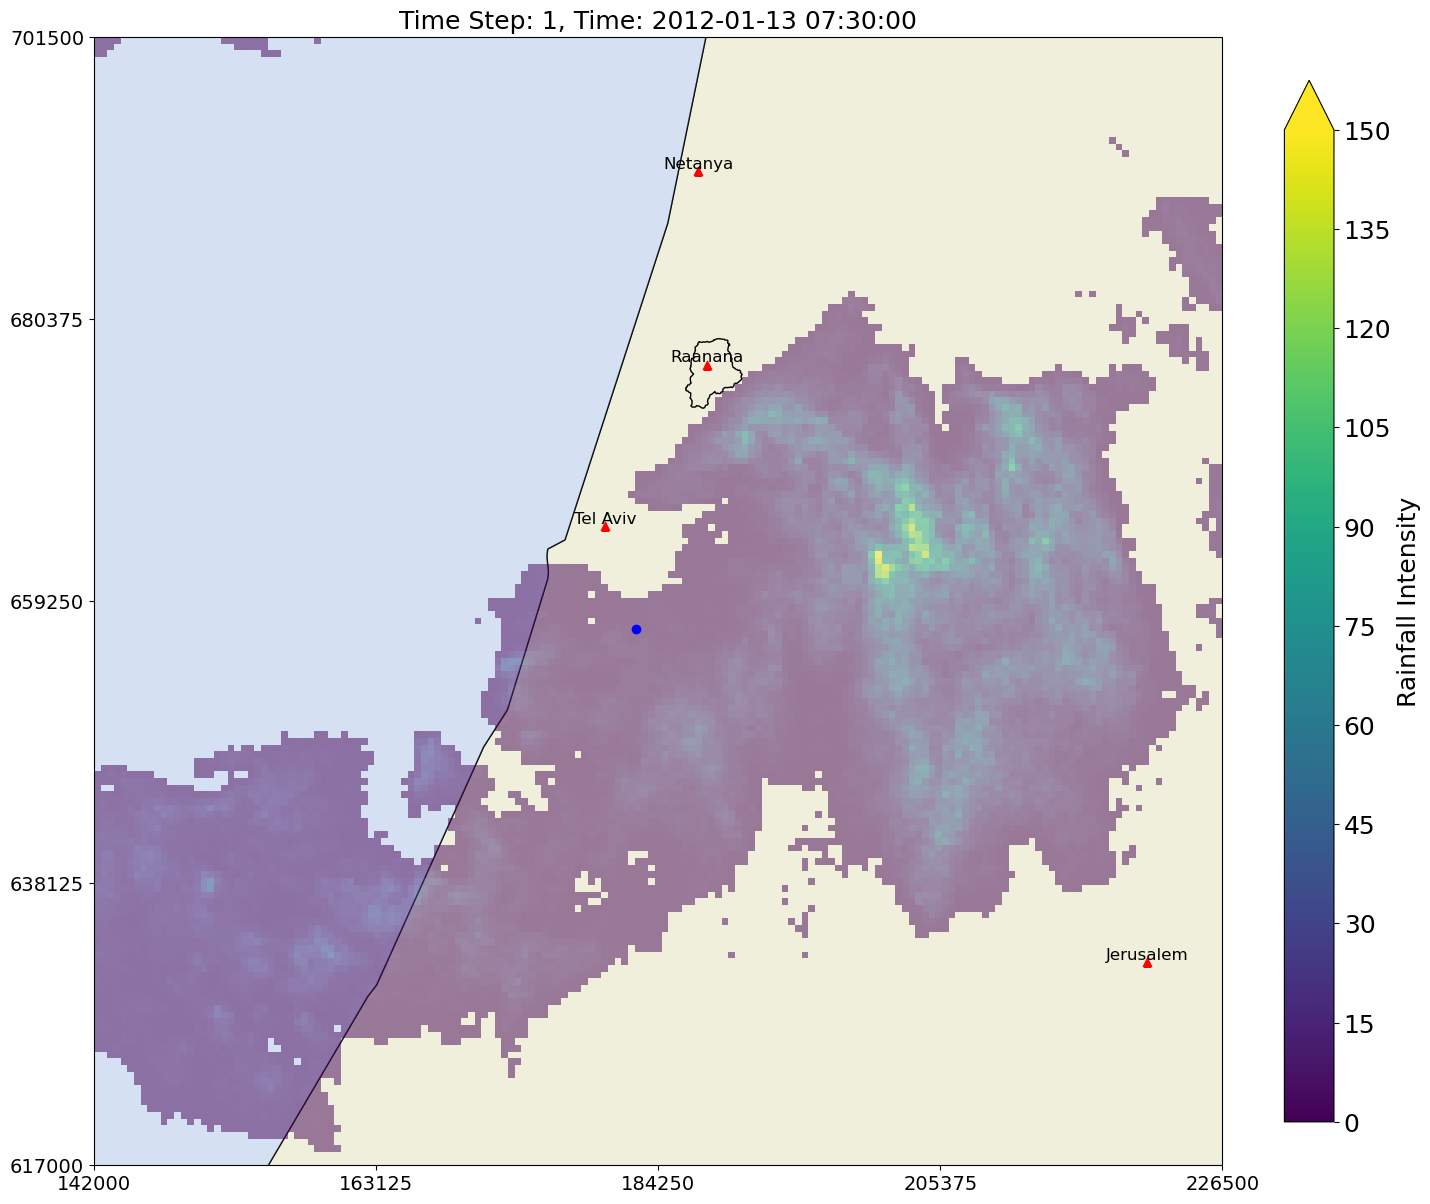

In [14]:
# Define the ITM projection
itm_crs = ccrs.epsg(2039)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(16, 16), subplot_kw={'projection': itm_crs})

# Create a dummy plot to ensure there is at least one collection available for the color bar
dummy_data = np.zeros((1, 1))
dummy_plot = ax.imshow(dummy_data, cmap='viridis', vmin=min_rain_value, vmax=max_rain_value)


# Define the update function for animation
def update(frame):
    ax.clear()
    ax.set_extent([xmin, xmax, ymin, ymax], crs=itm_crs)  # Set the extent of the axis
    
    raanana_gdf.to_crs(epsg=2039).plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)
    ax.add_feature(cfeature.LAND.with_scale('10m'), edgecolor='black')
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), edgecolor='black', alpha=0.4)
    
    radar_poly_grid_gdf, time = netCDF_process_radar_data(radar_filename, start_idx, array_len_idx, time_step = frame)
    radar_poly_grid_gdf.to_crs(epsg=2039).plot(ax=ax, alpha=0.5, column='rain', linewidth=0, cmap='viridis', edgecolor='black')

    dummy_plot.set_clim(min_rain_value, max_rain_value)  # Update color limits directly on dummy_plot
    ax.set_title(f'Time Step: {frame}, Time: {str(time[0])}', fontsize=18)
    
    # Plot radar location
    radar_coords = radar_nc['radar_location_ITM'][:]
#     ax.scatter(radar_coords[0], radar_coords[1], marker='o', color='blue', label='Radar Location')
    ax.scatter(182626, 657156, marker='o', color='blue', label='Radar Location')
    # Plot cities

    plot_city(ax, 'Jerusalem', jerusalem_coords_itm, color='red')
    plot_city(ax, 'Tel Aviv', tel_aviv_coords_itm, color='red')
    plot_city(ax, 'Netanya', netanya_coords_itm, color='red')
    plot_city(ax, 'Raanana', raanana_coords_itm, color='red')

    # Linearly interpolate to get additional ticks
    x_ticks = np.linspace(xmin, xmax, num=5)
    y_ticks = np.linspace(ymin, ymax, num=5)

    # Convert to integers
    x_ticks_int = [int(x) for x in x_ticks]
    y_ticks_int = [int(y) for y in y_ticks]

    # Set x and y tick labels
    ax.set_xticks(x_ticks_int)
    ax.set_yticks(y_ticks_int)
    ax.set_xticklabels(x_ticks_int, fontsize=14)
    ax.set_yticklabels(y_ticks_int, fontsize=14)

# Add color bar
cbar = plt.colorbar(dummy_plot, ax=ax, orientation='vertical', fraction=0.04, extend='max')
cbar.set_label('Rainfall Intensity', fontsize=18)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(np.linspace(min_rain_value, max_rain_value, num=11))

# Create animation
ani = animation.FuncAnimation(fig, update, frames=range(start_time, end_time + 1), interval=200)

directory = r'D:\Development\RESEARCH\Raanana\figures\Selected_storms_radar_gifs'
file_name = os.path.basename(radar_filename)
file_path = os.path.join(directory, file_name[:-3] + '_radar_animation.gif')

# Save animation
ani.save(file_path+'.gif', writer='Pillow', fps=2)  # For GIF
# ani.save(file_path+'.mp4'', writer='ffmpeg', fps=2)  # For MP4

plt.show()